In [1]:
import sqlite3
import pandas as pd
#THIS FILE WORKS WITH THE KAGGLE YOUTUBE DATASET WHICH WAS IMPORTED INTO DATA.DB
with sqlite3.connect('data.db') as connection:
    df = pd.read_sql_query("select * from YouTubeTable;", connection)
print("Opened db successfully")

Opened db successfully


In [2]:
print(df.head())
df.drop(columns = ["comments_disabled", "ratings_disabled", "video_error_or_removed", "trending_date"], inplace=True)
print(df.head())
print(df.info())
print(df.describe())

      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

  category_id              publish_time  \
0          22  2017-11-13T17:13:01.000Z   
1          24  2017-11-13T07:30:00.000Z   
2          23  2017-11-12T19:05:24.000Z   
3          24  2017-11-13T11:00:04.000Z   
4          24  2017-11-12T18:01:41.000Z   

                                                tags    views   likes  \


In [3]:
df.dropna(inplace=True)
df = df.reset_index(drop=True)
print("Null records dropped")
print(df.info())

Null records dropped
<class 'pandas.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   video_id        6475 non-null   str  
 1   title           6475 non-null   str  
 2   channel_title   6475 non-null   str  
 3   category_id     6475 non-null   str  
 4   publish_time    6475 non-null   str  
 5   tags            6475 non-null   str  
 6   views           6475 non-null   str  
 7   likes           6475 non-null   str  
 8   dislikes        6475 non-null   str  
 9   comment_count   6475 non-null   str  
 10  thumbnail_link  6475 non-null   str  
 11  description     6475 non-null   str  
dtypes: str(12)
memory usage: 607.2 KB
None


In [4]:
print(df.dtypes)
df = df.drop(index = 1093)

convert_dict = {"views": "int64", "likes": "int64", "dislikes": "int64", "comment_count": "int64"}
df = df.astype(convert_dict)
print(df.dtypes)

video_id          str
title             str
channel_title     str
category_id       str
publish_time      str
tags              str
views             str
likes             str
dislikes          str
comment_count     str
thumbnail_link    str
description       str
dtype: object
video_id            str
title               str
channel_title       str
category_id         str
publish_time        str
tags                str
views             int64
likes             int64
dislikes          int64
comment_count     int64
thumbnail_link      str
description         str
dtype: object


In [5]:
#for i in range(len(df)):
#    if df['publish_date'].loc[i] == "publish_date":
#        print("invalid")

In [6]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df.dtypes

video_id                          str
title                             str
channel_title                     str
category_id                       str
publish_time      datetime64[us, UTC]
tags                              str
views                           int64
likes                           int64
dislikes                        int64
comment_count                   int64
thumbnail_link                    str
description                       str
dtype: object

In [7]:
df.drop(columns = ['thumbnail_link'], inplace = True)
df = df.reset_index(drop = True)
df.head()

,video_id,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,description
0,2kyS6SvSYSE,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency""|""last week...",2418783,97185,6146,12703,"One year after the presidential election, John..."
2,5qpjK5DgCt4,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman""|""rudy""|""mancuso""|""king""|""bach...",3191434,146033,5339,8181,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link""|""gmm""|""good mythical morning""|...",343168,10172,666,2146,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan""|""higa""|""higatv""|""nigahiga""|""i dare you""|...",2095731,132235,1989,17518,I know it's been a while since we did this sho...


# What are some factors that lead to more popular videos?
## Data types established, irrelevant columns dropped, index reset
### Independent variables:
- title, category_id, publish_time, tags, description, channel_title
### Dependent Variable:
- views
## Potential Insights to gather:
- Title length factor, description length, most popular categories, popular tags, find patterns in most/least popular channels and/or videos

                  views     likes  dislikes  comment_count
views          1.000000  0.889289  0.496248       0.723862
likes          0.889289  1.000000  0.421871       0.842755
dislikes       0.496248  0.421871  1.000000       0.666520
comment_count  0.723862  0.842755  0.666520       1.000000


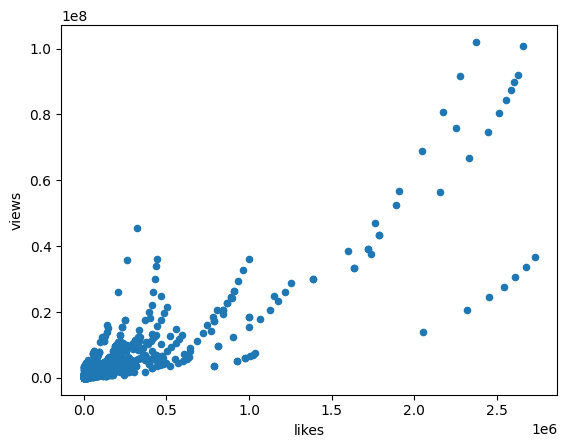

In [11]:
sub = df[['views', 'likes', 'dislikes', 'comment_count']]
#high correlation between likes-views, and comment_count-likes
import matplotlib.pyplot as plt
print(sub.corr())
sub.plot(kind = 'scatter', x = "likes", y = "views")
plt.show()

In [26]:
#I want the top 10 videos, channels, and categorys in terms of average views
print(df['views'].mean())
#print(df.nlargest(10, 'views'))
print(df.describe())
print(df['views'].quantile(.75))

1298128.781124498
              views         likes      dislikes  comment_count
count  6.474000e+03  6.474000e+03  6.474000e+03    6474.000000
mean   1.298129e+06  4.848278e+04  2.173283e+03    5567.601019
std    4.990344e+06  1.833923e+05  2.577853e+04   28697.126846
min    6.870000e+02  0.000000e+00  0.000000e+00       0.000000
25%    8.508400e+04  1.996500e+03  7.500000e+01     273.000000
50%    3.042315e+05  8.841500e+03  2.900000e+02    1013.500000
75%    9.512958e+05  2.834725e+04  1.008000e+03    3195.500000
max    1.020126e+08  2.729292e+06  1.353647e+06  827755.000000
951295.75
